In [1]:
%reset -f

[Veri] 131 adet LHS deney noktası yüklendi.

[Vekil Model] Gaussian Process Regressor eğitimi başlıyor...
  [deformation ] GPR eğitimi tamamlandı | CV R² = 0.9650
  [stress      ] GPR eğitimi tamamlandı | CV R² = 0.8476
  [life        ] GPR eğitimi tamamlandı | CV R² = 0.8740

 MODİFİYE KUTUP TİLKİSİ ALGORİTMASI – Optimizasyon Başladı
  Popülasyon  : 40
  Max İterasyon: 300
  Değişken sayısı: 8
  İter    1/300  | En İyi F = 1.346587  | Kütle ≈ 1.3466 kg
  İter   21/300  | En İyi F = 1.264850  | Kütle ≈ 1.2649 kg
  İter   41/300  | En İyi F = 1.251730  | Kütle ≈ 1.2517 kg
  İter   61/300  | En İyi F = 1.251730  | Kütle ≈ 1.2517 kg
  İter   81/300  | En İyi F = 1.239083  | Kütle ≈ 1.2391 kg
  İter  101/300  | En İyi F = 1.235790  | Kütle ≈ 1.2358 kg
  İter  121/300  | En İyi F = 1.232001  | Kütle ≈ 1.2320 kg
  İter  141/300  | En İyi F = 1.231830  | Kütle ≈ 1.2318 kg
  İter  161/300  | En İyi F = 1.227665  | Kütle ≈ 1.2277 kg
  İter  181/300  | En İyi F = 1.227204  | Kütle ≈ 1.2272 kg
  

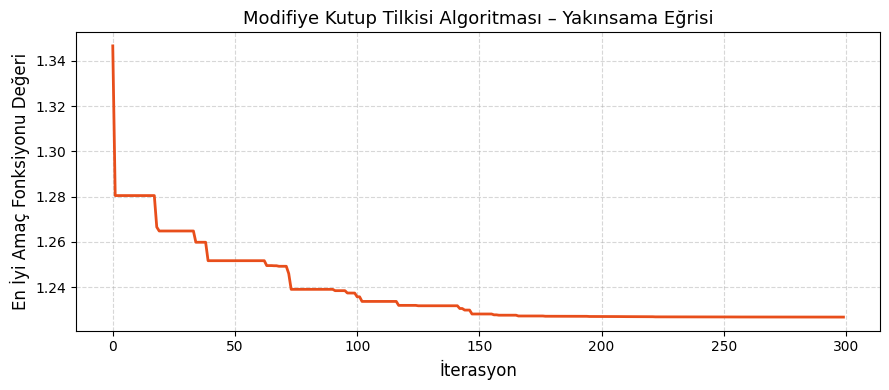

[Grafik] Değişken evrimi kaydedildi: variable_evolution.png


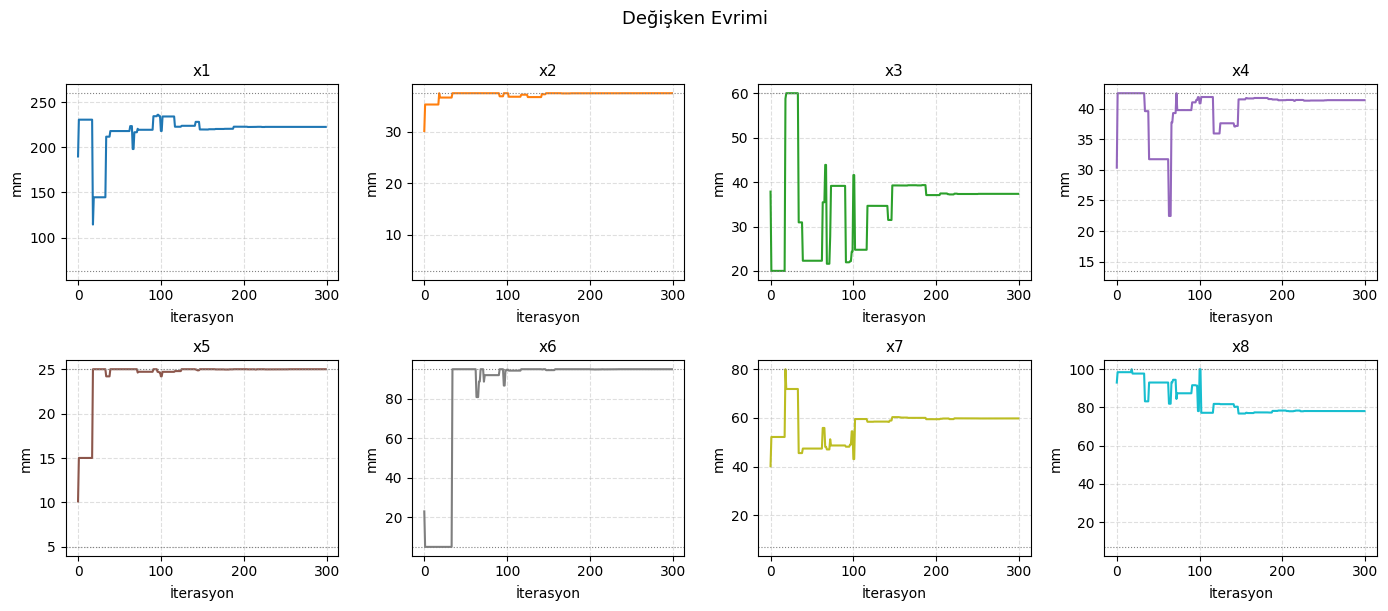


[Kayıt] Optimal çözüm 'optimal_solution.csv' dosyasına kaydedildi.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
import warnings
import math
warnings.filterwarnings("ignore")

SIGMA_AKMA = 235.0
SF         = 1.2
D_MIN      = 0.16067
D_MAX      = 0.16859
LIFE_MIN   = 1e7

R1 = 1e4
R2 = 1e4

BOUNDS = np.array([
    [63.01, 260.0],
    [3.01,  37.5 ],
    [20.01, 60.0 ],
    [13.51, 42.5 ],
    [5.0,   25.0 ],
    [5.0,   95.0 ],
    [7.0,   80.0 ],
    [7.0,   100.0],
])

N_VARS = BOUNDS.shape[0]  #değişken sayısını bulur

def load_lhs_data(csv_path: str) -> pd.DataFrame:

    """LHS CSV verisini yükler ve döndürür."""

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]  #Sütun isimlerinin başında veya sonunda olabilecek gereksiz boşlukları (örneğin " sıcaklık " yerine "sıcaklık") temizler.

    for col in df.columns:  #Tablodaki tüm sütunlar üzerinde tek tek işlem yapmak için bir döngü başlatır.

        df[col] = pd.to_numeric(df[col], errors='coerce')  #Sütundaki verileri sayısal tipe (float/int) çevirir. Eğer sayıya çevrilemeyen hatalı bir karakter (metin vb.) varsa, orayı NaN (boş veri) yapar.

    df.dropna(inplace=True)  #İçinde boş veya hatalı veri (NaN) bulunan tüm satırları tamamen siler; böylece sadece temiz ve tam sayısal veriler kalır.

    print(f"[Veri] {len(df)} adet LHS deney noktası yüklendi.")

    return df


def train_surrogate_models(df: pd.DataFrame):

    feature_cols = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]
    target_cols  = {
        "deformation": "Tot-Deformation-Max",
        "stress"     : "Stress-Max",
        "life"       : "Life-Min",
       # "mass"       : "Mass",
    }

    X = df[feature_cols].values

    scaler = MinMaxScaler()              #####  Bu neden gerekli ????
    X_scaled = scaler.fit_transform(X)

    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(N_VARS),
                                         length_scale_bounds=(1e-2, 1e2))    #Detayları sor
    models = {}

    for key, col in target_cols.items():   #Dört hedef (deformasyon, stres, yorulma, kütle) için döngü başlatır.
        y = df[col].values
        gpr = GaussianProcessRegressor(kernel=kernel,
                                        n_restarts_optimizer=5,
                                        normalize_y=True,
                                        random_state=42)

        gpr.fit(X_scaled, y)

        cv_r2 = cross_val_score(gpr, X_scaled, y, cv=5, scoring="r2").mean()  # 5-katlı çapraz doğrulama skoru
        print(f"  [{key:12s}] GPR eğitimi tamamlandı | CV R² = {cv_r2:.4f}")
        models[key] = gpr

    return scaler, models
def predict_responses(x: np.ndarray, scaler, models: dict) -> dict:
    """Vekil modellerden FEA çıktılarını tahmin eder."""
    x_s = scaler.transform(x.reshape(1, -1))

    W_baz = 1.5594277
    k = 0.0000196375

    eksiltilen_alan = (x[0] * x[1]) + (x[2] * x[3]) + (x[4] * x[5]) + (x[6] * x[7])

    hesaplanan_kutle = W_baz - (k * eksiltilen_alan)


    return {
        "deformation": models["deformation"].predict(x_s)[0],
        "stress"     : models["stress"].predict(x_s)[0],
        "life"       : models["life"].predict(x_s)[0],
        "mass"       : hesaplanan_kutle,
    }

def evaluate_constraints(x: np.ndarray, scaler, models: dict) -> dict:
    """
    Tüm kısıtları hesaplar.
    Negatif veya sıfır değer → kısıt sağlanıyor.
    Pozitif değer → ihlal miktarı.
    """
    resp = predict_responses(x, scaler, models)
    x1, x2, x3, x4 = x[0], x[1], x[2], x[3]

    g = {}

    g["g1_lower"] = D_MIN - resp["deformation"]

    g["g1_upper"] = resp["deformation"] - D_MAX

    g["g2"] = resp["stress"] - (SIGMA_AKMA / SF)

    g["g3"] = LIFE_MIN - resp["life"]

    g["g4"] = (x2 + x4) - 80.0

    g["g5"] = (x1 + x3) - 260.0

    return g, resp

def objective_function(x: np.ndarray, scaler, models: dict) -> float:
    """
    Cezalı amaç fonksiyonu:
    F_opt(x) = Kütle(x) + R1·max(0,g1)² + R2·max(0,g2)²
    Tüm kısıtlar için exterior penalty yöntemi uygulanır.
    """
    g, resp = evaluate_constraints(x, scaler, models)

    penalty = 0.0
    penalty += R1 * max(0.0, g["g1_lower"]) ** 2

    penalty += R1 * max(0.0, g["g1_upper"]) ** 2

    penalty += R2 * max(0.0, g["g2"]) ** 2

    penalty += R2 * max(0.0, g["g3"]) ** 2

    penalty += R1 * max(0.0, g["g4"]) ** 2

    penalty += R1 * max(0.0, g["g5"]) ** 2

    return resp["mass"] + penalty

class ModifiedArcticFoxOptimizer:

    def __init__(self,
                 n_foxes       : int   = 40,
                 max_iter      : int   = 200,
                 alpha         : float = 0.8,
                 beta          : float = 0.3,
                 gamma         : float = 0.98,
                 p_explore     : float = 0.7,
                 penalty_scale : float = 1.05,
                 random_state  : int   = 42):

        self.n_foxes       = n_foxes
        self.max_iter      = max_iter
        self.alpha         = alpha
        self.beta          = beta
        self.gamma         = gamma
        self.p_explore     = p_explore
        self.penalty_scale = penalty_scale
        self.rng           = np.random.default_rng(random_state)

        self.best_solution    = None
        self.best_fitness     = np.inf
        self.history_fitness  = []
        self.history_best_x   = []
        self.convergence_iter = None

    # ─────────────────────── yardımcı fonksiyonlar ──────────────────────── #

    def _clip(self, x: np.ndarray) -> np.ndarray:
        """Pozisyonu sınırlar içinde tutar."""
        return np.clip(x, BOUNDS[:, 0], BOUNDS[:, 1])

    def _initialize_population(self) -> np.ndarray:
        """Latin Hypercube benzeri başlangıç popülasyonu oluşturur."""
        pop = np.zeros((self.n_foxes, N_VARS))
        for j in range(N_VARS):
            lo, hi = BOUNDS[j]
            pop[:, j] = self.rng.uniform(lo, hi, self.n_foxes)
        return pop

    def _step_size(self, iteration: int, dimension: int) -> float:
        """Adaptif adım boyutu hesabı."""
        span = BOUNDS[dimension, 1] - BOUNDS[dimension, 0]
        return self.alpha * span * (self.gamma ** iteration)

    # ─────────────────────── ana algoritma ──────────────────────────────── #

    def optimize(self, scaler, models: dict, verbose: bool = True) -> dict:

        global R1, R2

        population = self._initialize_population()
        fitness    = np.array([objective_function(ind, scaler, models)
                                for ind in population])

        best_idx           = np.argmin(fitness)
        self.best_solution = population[best_idx].copy()
        self.best_fitness  = fitness[best_idx]

        if verbose:
            print("\n" + "="*65)
            print(" MODİFİYE KUTUP TİLKİSİ ALGORİTMASI – Optimizasyon Başladı")
            print("="*65)
            print(f"  Popülasyon  : {self.n_foxes}")
            print(f"  Max İterasyon: {self.max_iter}")
            print(f"  Değişken sayısı: {N_VARS}")
            print("="*65)

        for it in range(self.max_iter):     # ── İterasyon döngüsü ──

            # Adaptif keşif olasılığı (başta yüksek, sonda düşük)
            p_explore_it = self.p_explore * (1.0 - it / self.max_iter) + 0.1

            for i in range(self.n_foxes):
                new_pos = population[i].copy()

                for d in range(N_VARS):
                    step = self._step_size(it, d)

                    if self.rng.random() < p_explore_it:
                        # ── Keşif: Lévy uçuşu benzeri geniş atlama ──
                        levy     = self._levy_flight()
                        new_pos[d] = (population[i, d]
                                      + self.alpha * step * levy
                                      + self.rng.uniform(-1, 1) * step)
                    else:
                        # ── Sömürü: En iyi bireye yaklaşma ──
                        r1 = self.rng.random()
                        r2 = self.rng.random()
                        new_pos[d] = (population[i, d]
                                      + self.beta * r1
                                        * (self.best_solution[d] - population[i, d])
                                      + self.beta * r2 * step
                                        * self.rng.choice([-1, 1]))

                new_pos  = self._clip(new_pos)
                new_fit  = objective_function(new_pos, scaler, models)

                if new_fit < fitness[i]:       # Açgözlü kabul
                    population[i] = new_pos
                    fitness[i]    = new_fit

            best_idx_it = np.argmin(fitness)   # Elitizm: En iyi bireyi koru
            if fitness[best_idx_it] < self.best_fitness:
                self.best_solution = population[best_idx_it].copy()
                self.best_fitness  = fitness[best_idx_it]
                self.convergence_iter = it

            # ── Adaptif ceza güncelleme ──
            g_vals, _ = evaluate_constraints(self.best_solution, scaler, models)
            any_violation = any(v > 0 for v in g_vals.values())
            if any_violation:
                R1 *= self.penalty_scale
                R2 *= self.penalty_scale

            self.history_fitness.append(self.best_fitness)
            self.history_best_x.append(self.best_solution.copy())

            if verbose and (it % 20 == 0 or it == self.max_iter - 1):
                print(f"  İter {it+1:4d}/{self.max_iter}  "
                      f"| En İyi F = {self.best_fitness:.6f}  "
                      f"| Kütle ≈ {self._estimate_mass(scaler, models):.4f} kg")

        if verbose:
            print("="*65)
            print(" OPTİMİZASYON TAMAMLANDI")
            print("="*65)

        return {
            "best_x"         : self.best_solution,
            "best_fitness"   : self.best_fitness,
            "history_fitness": self.history_fitness,
            "history_best_x" : self.history_best_x,
        }

    def _levy_flight(self, beta_levy: float = 1.5) -> float:
        """Lévy uçuşu örneklemesi (Mantegna algoritması)."""
        num   = math.gamma(1 + beta_levy) * np.sin(np.pi * beta_levy / 2) # Changed np.math.gamma to math.gamma
        den   = (math.gamma((1 + beta_levy) / 2) # Changed np.math.gamma to math.gamma
                 * beta_levy
                 * 2 ** ((beta_levy - 1) / 2))
        sigma = (num / den) ** (1 / beta_levy)
        u = self.rng.normal(0, sigma)
        v = self.rng.normal(0, 1)
        return u / (abs(v) ** (1 / beta_levy))

    def _estimate_mass(self, scaler, models) -> float:
        resp = predict_responses(self.best_solution, scaler, models)
        return resp["mass"]

def print_results(result: dict, scaler, models: dict):
    """Optimizasyon sonuçlarını ekrana yazdırır."""
    x_opt = result["best_x"]
    g_vals, resp = evaluate_constraints(x_opt, scaler, models)

    var_names = ["x1 (YB-01)", "x2 (YB-02)", "x3 (AB-01)", "x4 (AB-02)",
                 "x5 (KB-01)", "x6 (KB-02)", "x7 (OB-01)", "x8 (OB-02)"]

    print("\n" + "="*65)
    print("  OPTİMAL ÇÖZÜM")
    print("="*65)
    print("  Karar Değişkenleri:")
    for i, (name, val) in enumerate(zip(var_names, x_opt)):
        lo, hi = BOUNDS[i]
        print(f"    {name:15s} = {val:8.3f} mm  [{lo:.2f}, {hi:.2f}]")

    print("\n  FEA Yanıt Tahminleri:")
    print(f"    Kütle            = {resp['mass']:.4f} kg")
    print(f"    Max Deformasyon  = {resp['deformation']:.6f} mm")
    print(f"    Max Gerilme      = {resp['stress']:.4f} MPa")
    print(f"    Min Yorulma Ömrü = {resp['life']:.3e} cycle")

    print("\n  Kısıt Değerlendirmesi:")
    for name, val in g_vals.items():
        status = "✓ Sağlandı" if val <= 0 else "✗ İhlal Edildi"
        print(f"    {name}: {val:+.4f}  →  {status}")

    print(f"\n  Amaç Fonksiyonu (Cezalı): {result['best_fitness']:.6f}")
    print("="*65)


def plot_convergence(history_fitness: list, save_path: str = None):
    """Yakınsama grafiğini çizer."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(history_fitness, color="#e84e1b", linewidth=2)
    ax.set_xlabel("İterasyon", fontsize=12)
    ax.set_ylabel("En İyi Amaç Fonksiyonu Değeri", fontsize=12)
    ax.set_title("Modifiye Kutup Tilkisi Algoritması – Yakınsama Eğrisi", fontsize=13)
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"[Grafik] Yakınsama eğrisi kaydedildi: {save_path}")
    plt.show()


def plot_variable_evolution(history_best_x: list, save_path: str = None):
    """Değişken evrimini çizer."""
    arr        = np.array(history_best_x)
    var_names  = ["x1","x2","x3","x4","x5","x6","x7","x8"]
    colors     = plt.cm.tab10(np.linspace(0, 1, N_VARS))

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    axes = axes.flatten()
    for j, (ax, name, color) in enumerate(zip(axes, var_names, colors)):
        ax.plot(arr[:, j], color=color, linewidth=1.5)
        ax.axhline(BOUNDS[j, 0], color="gray", linestyle=":", linewidth=0.8)
        ax.axhline(BOUNDS[j, 1], color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("İterasyon")
        ax.set_ylabel("mm")
        ax.grid(True, linestyle="--", alpha=0.4)
    plt.suptitle("Değişken Evrimi", fontsize=13, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[Grafik] Değişken evrimi kaydedildi: {save_path}")
    plt.show()

def main():
    CSV_PATH = "LHS.csv"   # <── LHS verisi dosya yolunu buraya girin

    # ── Veri yükleme ──
    df = load_lhs_data(CSV_PATH)

    # ── Vekil model eğitimi ──
    print("\n[Vekil Model] Gaussian Process Regressor eğitimi başlıyor...")
    scaler, models = train_surrogate_models(df)

    # ──────────────────────────────────────────────────────────
    # ALGORİTMA PARAMETRELERİ – İstediğiniz gibi değiştirebilirsiniz
    # ──────────────────────────────────────────────────────────
    optimizer = ModifiedArcticFoxOptimizer(
        n_foxes       = 40,    # Popülasyon büyüklüğü
        max_iter      = 300,   # Maksimum iterasyon
        alpha         = 0.8,   # Keşif adım katsayısı
        beta          = 0.35,  # Sömürü katsayısı
        gamma         = 0.97,  # Adım sönümleme oranı
        p_explore     = 0.65,  # Başlangıç keşif olasılığı
        penalty_scale = 1.02,  # Adaptif ceza artış katsayısı
        random_state  = 42,
    )

    # ── Optimizasyon ──
    result = optimizer.optimize(scaler, models, verbose=True)

    # ── Sonuçlar ──
    print_results(result, scaler, models)

    # ── Grafikler ──
    plot_convergence(result["history_fitness"],
                     save_path="convergence_curve.png")
    plot_variable_evolution(result["history_best_x"],
                            save_path="variable_evolution.png")

    # ── Sonuçları CSV'ye kaydet ──
    x_opt = result["best_x"]
    _, resp = evaluate_constraints(x_opt, scaler, models)
    summary = {f"x{i+1}": x_opt[i] for i in range(N_VARS)}
    summary.update({
        "Mass_opt"       : resp["mass"],
        "Deformation_opt": resp["deformation"],
        "Stress_opt"     : resp["stress"],
        "Life_opt"       : resp["life"],
        "F_opt"          : result["best_fitness"],
    })
    pd.DataFrame([summary]).to_csv("optimal_solution.csv", index=False)
    print("\n[Kayıt] Optimal çözüm 'optimal_solution.csv' dosyasına kaydedildi.")


if __name__ == "__main__":
    main()